# Classification of b-quark jets in the Aleph simulated data

Python macro for selecting b-jets (sprays of particles with a b-quark in it) in Aleph Z -> qqbar MC (i.e. simulated decays of the Z0 boson decaying to a quark and an anti-quark) in various ways:
* Initially, simply with "if"-statements making requirements on certain variables. This corresponds to selecting "boxes" in the input variable space (typically called "X"). One could also try a Fisher discriminant (linear combination of input variables), which corresponds to a plane in the X-space. But as the problem is non-linear, it is likely to be sub-optimal.

* Next using Machine Learning (ML) methods. We will during the first week try both (Boosted) Decision Tree ((B)DT) based and Neural Net (NN) based methods, and see how complicated (or not) it is to get a good solution, and how much better it performs compared to the "classic" selection method.

Once you obtain a classification of b-jets vs. non-b-jets, think about how to quantify the quality of your algorithm. Also, try to compare it to the NN result of the Aleph collaboration, given by the variable "nnbjet". It is based on a neural network with 6 input variables (prob_b, spheri, pt2rel, multip, bqvjet, and ptlrel), and two hidden layers each with 10 nodes in. Can you do better?

In the end, this exercise is the simple start on moving into the territory of Machine Learning analysis.


### Data:
The input variables (X) are (where Aleph uses only the first six):
* **prob_b**: Probability of being a b-jet from the pointing of the tracks to the vertex.
* **spheri**: Sphericity of the event, i.e. how spherical it is.
* **pt2rel**: The transverse momentum squared of the tracks relative to the jet axis, i.e. width of the jet.
* **multip**: Multiplicity of the jet (in a relative measure).
* **bqvjet**: b-quark vertex of the jet, i.e. the probability of a detached vertex.
* **ptlrel**: Transverse momentum (in GeV) of possible lepton with respect to jet axis (about 0 if no leptons).
* energy: Measured energy of the jet in GeV. Should be 45 GeV, but fluctuates.
* cTheta: cos(theta), i.e. the polar angle of the jet with respect to the beam axis. Note, that the detector works best in the central region (|cTheta| small) and less well in the forward regions.
* phi:    The azimuth angle of the jet. As the detector is uniform in phi, this should not matter (much).

The target variable (Y) is:
* isb:    1 if it is from a b-quark and 0, if it is not.

Finally, those before you (the Aleph collaboration in the mid 90'ies) produced a Neural Net (6 input variables, two hidden layers with 10 neurons in each, and 1 output varible) based classification variable, which you can compare to (and compete with?):
* nnbjet: Value of original Aleph b-jet tagging algorithm, using only the last six variables (for reference).


### Task:
Thus, the task before you is to produce functions (non-ML and then ML algorithm), which given the input variables X provides an output variable estimate, Y_est, which is "closest possible" to the target variable, Y. The "closest possible" is left to the user to define in a _Loss Function_, which we will discuss further. In classification problems (such as this), the typical loss function to use "Cross Entropy", see https://en.wikipedia.org/wiki/Cross_entropy.

Once you have results, you're welcome to continue with a Fisher Linear Discriminant, and you may also challenge yourself by considering "v1" of the data, which is a little less "polished and ready". If you also manage this, then don't hold back in applying a real ML algorithm to the problem (you can get inspiration from "ML_MethodsDemos.ipynb" or the vast internet). A suggestion might be XGBoost or LightGBM.

* Author: Jonathan O. Melcher, Jakob B. Frederiksen & Troels C. Petersen (NBI)
* Email:  petersen@nbi.dk
* Date:   23rd of April 2026

In [3]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
from matplotlib import pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import numpy as np
import csv

Possible other packages to consider:
cornerplot, seaplot, sklearn.decomposition(PCA)

In [4]:
r = np.random
r.seed(42)

SavePlots = False
plt.close('all')

# Tree based solutions:

In the following we don't just provide tree based solutions from XGBoost and LightGBM, but also compare these for different sample sizes in terms of:
1. Model performance
2. Training time

While the performance is rather constant with different computers (it runs the same algorithm) the speed differs a lot, also in time/version. Run the code to see how these two algorithms run on your computer, and especially note how the performance keeps increasing with sample size, though at a slower and slower pace.

In order to test a large range, we use the full Aleph dataset, so you need to get the files from the Week1 webpage.

In [7]:
import pandas as pd
# Get data (with this very useful NumPy reader):
data0 = np.genfromtxt('AlephBtag_MC_train_Nev5000.csv', names=True)    # For faster running
data1 = np.genfromtxt('AlephBtag_MC_train_Nev50000.csv', names=True)   # For more data
data2 = np.genfromtxt('AlephBtag_MC_train_Nev500000.csv', names=True, delimiter=",")  # For even more data
data3 = np.genfromtxt('AlephBtag_MC_train_Nev5000000.csv', names=True) # For even more data

# Combine the data:
data = np.concatenate((data0, data1, data2, data3))

# Get the variables:
prob_b = data['prob_b']
spheri = data['spheri']
pt2rel = data['pt2rel']
multip = data['multip']
bqvjet = data['bqvjet']
ptlrel = data['ptlrel']

isb = data['isb']

In [14]:
# Test data:
data4 = np.genfromtxt('AlephBtag_MC_test_Nev246390.csv', names=True, delimiter=",")
prob_b_test = data4['prob_b']
spheri_test = data4['spheri']
pt2rel_test = data4['pt2rel']
multip_test = data4['multip']
bqvjet_test = data4['bqvjet']
ptlrel_test = data4['ptlrel']

isb_test = data4['isb']

In [15]:
# Splitting the data:
X = np.array([prob_b, spheri, pt2rel, multip, bqvjet, ptlrel, isb]).T
X = pd.DataFrame(X, columns=['prob_b', 'spheri', 'pt2rel', 'multip', 'bqvjet', 'ptlrel', 'isn']) 
X_test = np.array([prob_b_test, spheri_test, pt2rel_test, multip_test, bqvjet_test, ptlrel_test, isb_test]).T
X_test = pd.DataFrame(X_test, columns=['prob_b', 'spheri', 'pt2rel', 'multip', 'bqvjet', 'ptlrel', 'isn'])

In [16]:
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import lightgbm as lgb 
import xgboost as xgb
import time

In [17]:
# The sample sizes that we will use:
np.logspace(np.log10(5_000), np.log10(5_000_000), 10)

array([   5000.        ,   10772.17345016,   23207.94416806,
         50000.        ,  107721.73450159,  232079.44168064,
        500000.        , 1077217.34501594, 2320794.41680639,
       5000000.        ])

In [18]:
# We want to compare LGB and XGB comparing the time it takes to train and the accuracy of the model for different sample sizes
def compare(df_run, df_test):
    times_lgb = []
    times_std_lgb = []
    times_xgb = []
    times_std_xgb = []
    accuracy_lgb = []
    accuracy_std_lgb = []
    accuracy_xgb = []
    accuracy_std_xgb = []
    X_test = df_test.drop(['isn'], axis=1)
    y_test = df_test['isn']

    # Loop over different sample sizes
    for i in np.logspace(np.log10(5_000), np.log10(2_000_000), 8, dtype=int):
        times_lgb_temp = []
        times_xgb_temp = []
        accuracy_lgb_temp = []
        accuracy_xgb_temp = []

        # We train 3 times to get variation/uncertainty:
        for _ in range(3):
            data_frame = df_run.sample(i)
            X_train = data_frame.drop('isn', axis=1)
            y_train = data_frame['isn']

            # Performance and time for LGB
            data_train = lgb.Dataset(X_train, label=y_train)
            params = {'objective': 'binary',
                'boosting_type': 'gbdt',
                'metric': 'binary_logloss',
                'learning_rate': 0.02,
                'num_leaves': 10,
                'max_depth': 10,
                'min_data': 10,
                'verbose': 0,
                'force_col_wise': True}
          
            start = time.time()
            lgb_model = lgb.train(params, data_train, 500)
            end = time.time()
            times_lgb_temp.append(end-start)
            accuracy_lgb_temp.append(accuracy_score(y_test, lgb_model.predict(X_test) > 0.5))
          
            # Performance and time for XGB
            xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)

            start = time.time()
            xgb_model.fit(X_train, y_train)
            end = time.time()
            times_xgb_temp.append(end-start)
            accuracy_xgb_temp.append(accuracy_score(y_test, xgb_model.predict(X_test) > 0.5))

        # Print progress:
        str_lgb = f"    LGB: Time {np.mean(times_lgb_temp):5.2f}s  Performance {np.mean(accuracy_lgb_temp):6.4f}"
        str_xgb = f"    XGB: Time {np.mean(times_xgb_temp):5.2f}s  Performance {np.mean(accuracy_xgb_temp):6.4f}"
        print(f"  Sample size: {i:8d}" + str_lgb + str_xgb)

        times_lgb.append(np.mean(times_lgb_temp))
        times_std_lgb.append(np.std(times_lgb_temp)/np.sqrt(5))
        times_xgb.append(np.mean(times_xgb_temp))
        times_std_xgb.append(np.std(times_xgb_temp)/np.sqrt(5))
        accuracy_lgb.append(np.mean(accuracy_lgb_temp))
        accuracy_std_lgb.append(np.std(accuracy_lgb_temp)/np.sqrt(5))
        accuracy_xgb.append(np.mean(accuracy_xgb_temp))
        accuracy_std_xgb.append(np.std(accuracy_xgb_temp)/np.sqrt(5))

    return times_lgb, times_std_lgb, times_xgb, times_std_xgb, accuracy_lgb, accuracy_std_lgb, accuracy_xgb, accuracy_std_xgb

In [19]:
times_lgb, times_std_lgb, times_xgb, times_std_xgb, accuracy_lgb, accuracy_std_lgb, accuracy_xgb, accuracy_std_xgb = compare(X, X_test)

  Sample size:     4999    LGB: Time  0.30s  Performance 0.8980    XGB: Time  0.12s  Performance 0.8889
  Sample size:    11767    LGB: Time  0.33s  Performance 0.9001    XGB: Time  0.10s  Performance 0.8935
  Sample size:    27695    LGB: Time  0.41s  Performance 0.9011    XGB: Time  0.13s  Performance 0.8969
  Sample size:    65183    LGB: Time  0.65s  Performance 0.9015    XGB: Time  0.18s  Performance 0.8994
  Sample size:   153412    LGB: Time  1.39s  Performance 0.9018    XGB: Time  0.33s  Performance 0.9015
  Sample size:   361064    LGB: Time  2.94s  Performance 0.9020    XGB: Time  0.69s  Performance 0.9023
  Sample size:   849781    LGB: Time  8.12s  Performance 0.9023    XGB: Time  2.57s  Performance 0.9029
  Sample size:  2000000    LGB: Time 24.66s  Performance 0.9022    XGB: Time  7.75s  Performance 0.9032


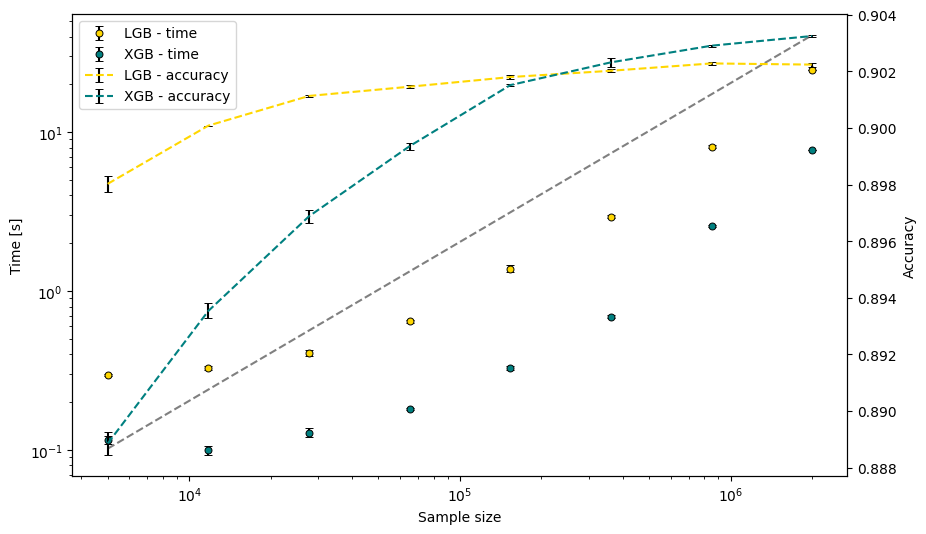

In [20]:
# Make a 2 y axis plot showing both timing (left) and accuracy (right):
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.logspace(np.log10(5_000), np.log10(2_000_000), 8, dtype=int), times_lgb, yerr=times_std_lgb, label='LGB - time', fmt='o', mec='k', mfc='gold', ms=5, mew=0.7, capsize=3, capthick=1, ecolor='k')
ax.errorbar(np.logspace(np.log10(5_000), np.log10(2_000_000), 8, dtype=int), times_xgb, yerr=times_std_xgb, label='XGB - time', fmt='o', mec='k', mfc='teal', ms=5, mew=0.7, capsize=3, capthick=1, ecolor='k')
ax1 = ax.twinx()
ax1.errorbar(np.logspace(np.log10(5_000), np.log10(2_000_000), 8, dtype=int), accuracy_lgb, yerr=accuracy_std_lgb, label='LGB - accuracy', fmt='--', ms=5, mew=0.7, capsize=3, capthick=1, ecolor='k', mfc='gold',color='gold')
ax1.errorbar(np.logspace(np.log10(5_000), np.log10(2_000_000), 8, dtype=int), accuracy_xgb, yerr=accuracy_std_xgb, label='XGB - accuracy', fmt='--', ms=5, mew=0.7, capsize=3, capthick=1, ecolor='k', mfc='gold',color='teal')
ax.set_xlabel('Sample size')
ax.set_ylabel('Time [s]')
ax1.set_ylabel('Accuracy')
ax.set_yscale('log')
ax.set_xscale('log')
## add the two legends to the plot
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc=0)
N_size = np.logspace(np.log10(5_000), np.log10(2_000_000))
ax.plot(N_size, N_size**(1)/(N_size[0]**(1))*times_lgb[2]/4.0, label='N^1', color='gray', linestyle='--')
plt.show()
fig.savefig("XGBoostVsLightGBM_AccuracyAndTime.png")